In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Install required packages
!pip install mne ssqueezepy --quiet


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.7/127.7 kB 9.4 MB/s eta 0:00:00


In [ ]:
#. Install Required Packages
!pip install torch torchvision torchaudio --quiet
!pip install torch-geometric -f https://data.pyg.org/whl/torch-2.0.0+cpu.html

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 77.4 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.0.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 

In [ ]:
# ====================== 1. Setup ======================
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATConv, global_max_pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# ====================== 2. Load CSV ======================
df = pd.read_csv("/content/drive/MyDrive/SCT_CN_AD_features_combined.csv")
#df = pd.read_csv("/content/drive/MyDrive/SCT_CN_FTD_features_combined_02.csv")
#df = pd.read_csv("/content/drive/MyDrive/features_combined.csv")


# Channels and label map
channels = ['Fp1','Fp2','F3','F4','C3','C4','P3','P4','O1','O2',
            'F7','F8','T3','T4','T5','T6','Fz','Cz','Pz']

label_map = {'AD': 0, 'CN': 1}
#label_map = {'FTD': 1, 'CN': 0}
#label_map = {'FTD': 0, 'CN': 1, }
num_channels = len(channels)

In [ ]:
# # # ====================== 3. Dynamic Edge Construction ======================
# # # ######################### Pearson correlation coefficient ####################
# def get_dynamic_edge_index(x, threshold=0.25):
#     corr = np.corrcoef(x)
#     edge_list = [(i, j) for i in range(num_channels) for j in range(num_channels)
#                  if i != j and abs(corr[i, j]) > threshold]
#     if not edge_list:
#         edge_list = [(i, (i + 1) % num_channels) for i in range(num_channels)]
#     return torch.tensor(edge_list, dtype=torch.long).t()


# # # ##### K-Nearest Neighbors Graphs ########
from sklearn.metrics.pairwise import cosine_similarity

def get_knn_edge_index(x, k=2):
    sim_matrix = cosine_similarity(x)
    edge_list = []
    for i in range(x.shape[0]):
        topk = np.argsort(sim_matrix[i])[-(k+1):]  # include self
        for j in topk:
            if i != j:
                edge_list.append((i, j))
    return torch.tensor(edge_list, dtype=torch.long).t()


In [ ]:
# ====================== 4. Row to Graph ======================
def row_to_graph(row):
    x = []
    for ch in channels:
        x.append([
            row[f"{ch}_delta"], row[f"{ch}_theta"],
            row[f"{ch}_alpha"], row[f"{ch}_beta"],
            row[f"{ch}_gamma"]
        ])
    x = torch.tensor(x, dtype=torch.float)
    edge_index = get_knn_edge_index(x.numpy(), k=4)  # 🔄 KNN-based edge construction
    #edge_index = get_dynamic_edge_index(x.numpy(), threshold=0.3)
    y = torch.tensor([label_map[row['label']]], dtype=torch.long)
    return Data(x=x, edge_index=edge_index, y=y)

graphs = [row_to_graph(row) for _, row in df.iterrows()]

In [ ]:
# ====================== 5. Split and Loaders ======================
train_graphs, test_graphs = train_test_split(
    graphs, test_size=0.2, stratify=df['label'], random_state=42
)
train_loader = DataLoader(train_graphs, batch_size=16, shuffle=True)
test_loader = DataLoader(test_graphs, batch_size=16)


In [ ]:
# ====================== 6. GAT Model ======================
class EEG_GAT_Dropout(nn.Module):
    def __init__(self, in_channels=5, hidden_channels=25, heads=4, dropout=0.2, num_classes=3):
        super().__init__()
        self.gat1 = GATConv(in_channels, hidden_channels, heads=heads, concat=True, dropout=dropout)
        self.gat2 = GATConv(hidden_channels * heads, hidden_channels, dropout=dropout)
        self.fc = nn.Linear(hidden_channels, num_classes)
        self.dropout = dropout

    def forward(self, x, edge_index, batch):
        x = F.elu(self.gat1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.elu(self.gat2(x, edge_index))
        x = global_max_pool(x, batch)
        return self.fc(x)

model = EEG_GAT_Dropout().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)
loss_fn = nn.CrossEntropyLoss()


In [ ]:
# ====================== 7. Training ======================
for epoch in range(1, 101):
    model.train()
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.batch)
        loss = loss_fn(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if epoch % 10 == 0:
        print(f"📊 Epoch {epoch}, Loss: {total_loss:.4f}")


📊 Epoch 10, Loss: 2.6674
📊 Epoch 20, Loss: 2.7238
📊 Epoch 30, Loss: 2.4355
📊 Epoch 40, Loss: 2.1900
📊 Epoch 50, Loss: 2.3693
📊 Epoch 60, Loss: 1.7882
📊 Epoch 70, Loss: 1.9680
📊 Epoch 80, Loss: 2.3322
📊 Epoch 90, Loss: 1.5444
📊 Epoch 100, Loss: 1.2880


In [ ]:
# # ====================== 8. Evaluation -- AD/CN  ======================
# model.eval()
# y_true, y_pred = [], []
# with torch.no_grad():
#     for batch in test_loader:
#         batch = batch.to(device)
#         out = model(batch.x, batch.edge_index, batch.batch)
#         pred = out.argmax(dim=1)
#         y_true.extend(batch.y.cpu().numpy())
#         y_pred.extend(pred.cpu().numpy())

# acc = accuracy_score(y_true, y_pred)
# print(f"\n✅ GAT Test Accuracy: {acc:.2%}")
# print(classification_report(y_true, y_pred, target_names=['AD', 'CN']))


✅ GAT Test Accuracy: 92.31%
              precision    recall  f1-score   support

          AD       1.00      0.86      0.92         7
          CN       0.86      1.00      0.92         6

    accuracy                           0.92        13
   macro avg       0.93      0.93      0.92        13
weighted avg       0.93      0.92      0.92        13



In [ ]:
# ====================== 8. Evaluation -- AD/FTD/CN  ======================
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index, batch.batch)
        pred = out.argmax(dim=1)
        y_true.extend(batch.y.cpu().numpy())
        y_pred.extend(pred.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
print(f"\n✅ GAT Test Accuracy: {acc:.2%}")
print(classification_report(y_true, y_pred, target_names=['AD', 'CN', 'FTD']))


✅ GAT Test Accuracy: 77.78%
              precision    recall  f1-score   support

          AD       1.00      0.43      0.60         7
          CN       0.60      1.00      0.75         6
         FTD       1.00      1.00      1.00         5

    accuracy                           0.78        18
   macro avg       0.87      0.81      0.78        18
weighted avg       0.87      0.78      0.76        18



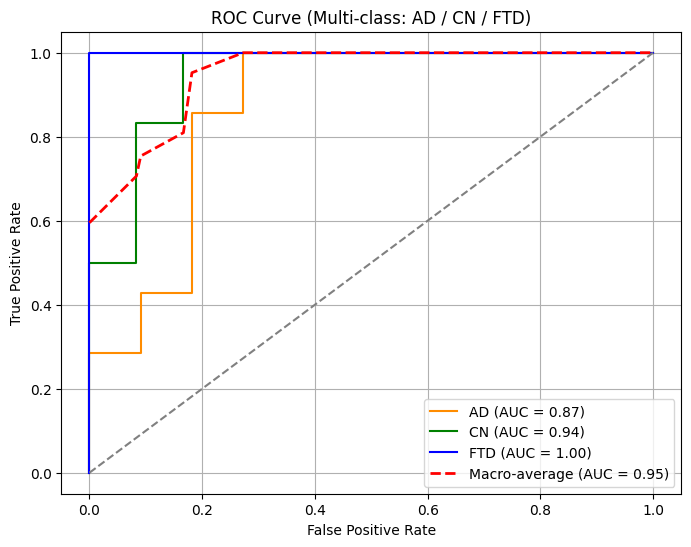

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt

# --- Convert y_true and predictions to probabilities ---
y_true_bin = label_binarize(y_true, classes=[0, 1, 2])  # AD=0, CN=1, FTD=2
n_classes = y_true_bin.shape[1]

# Get prediction probabilities
y_score = []
model.eval()
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index, batch.batch)  # shape [batch_size, 3]
        y_score.append(out.cpu().numpy())
y_score = np.vstack(y_score)  # shape [total_samples, 3]

# --- Plot ROC for each class ---
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute macro-average ROC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
roc_auc["macro"] = auc(all_fpr, mean_tpr)

# --- Plot ---
plt.figure(figsize=(8, 6))
colors = ['darkorange', 'green', 'blue']
class_names = ['AD', 'CN', 'FTD']

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})")

# Macro-average
plt.plot(all_fpr, mean_tpr, color='red', linestyle='--',
         label=f"Macro-average (AUC = {roc_auc['macro']:.2f})", linewidth=2)

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Multi-class: AD / CN / FTD)')
plt.legend(loc="lower right")
plt.grid()
plt.show()


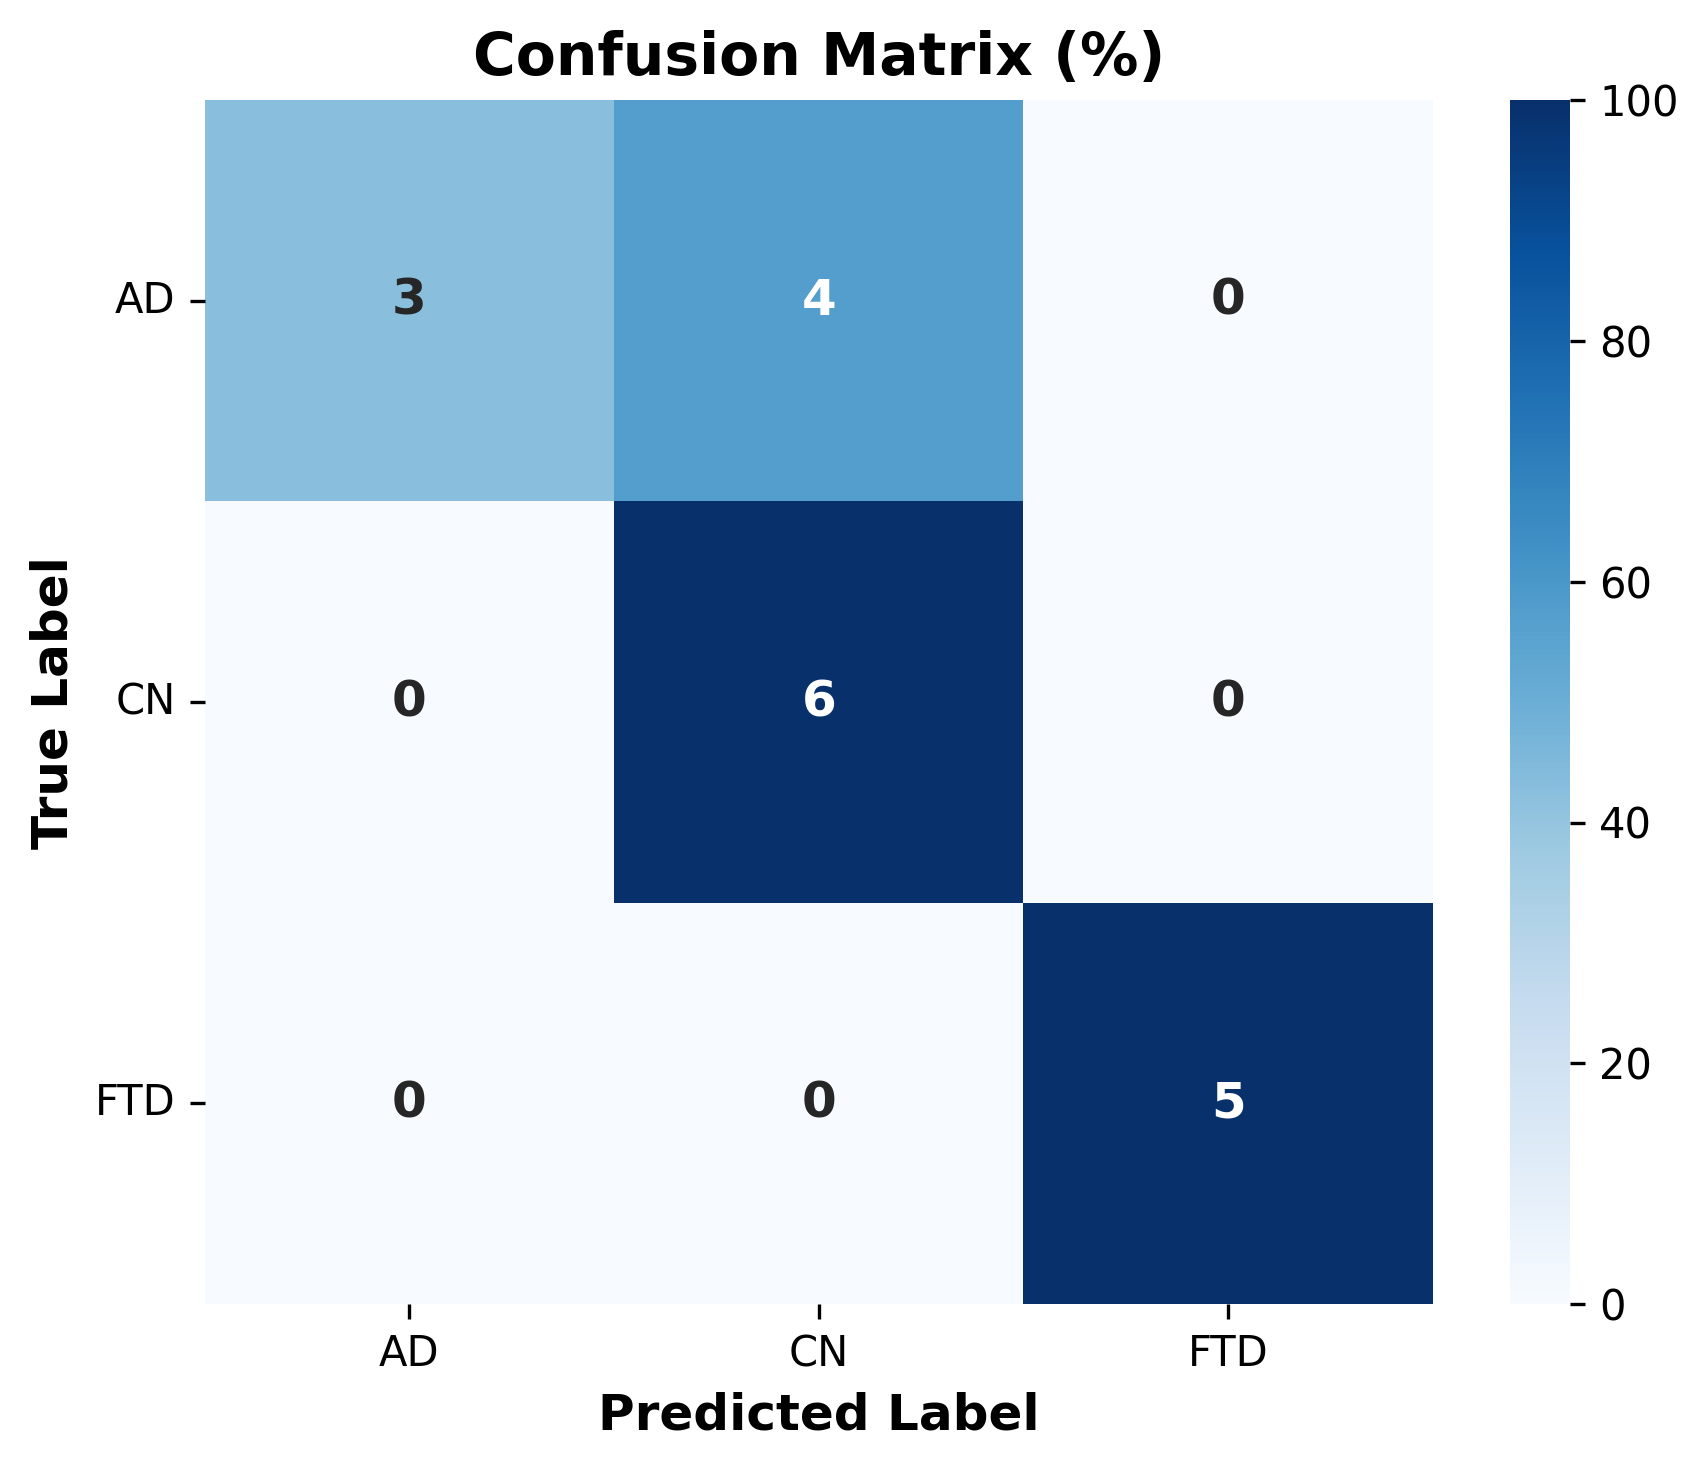

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_confusion_matrix(y_true, y_pred, class_names=['AD', 'CN', 'FTD']):
    cm = confusion_matrix(y_true, y_pred)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    plt.figure(figsize=(6, 5), dpi=300)  # High resolution
    sns.heatmap(cm_percent, annot=cm, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                annot_kws={"size": 12, "weight": "bold"})

    plt.ylabel('True Label', fontsize=12, weight='bold')
    plt.xlabel('Predicted Label', fontsize=12, weight='bold')
    plt.title('Confusion Matrix (%)', fontsize=14, weight='bold')
    plt.yticks(rotation=0)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
plot_confusion_matrix(y_true, y_pred)

In [ ]:
# Initialize accuracy logs
train_acc_list = []
test_acc_list = []

for epoch in range(1, 101):
    model.train()
    total_loss = 0
    y_true_train, y_pred_train = [], []

    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.batch)
        loss = loss_fn(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        # Collect predictions for training accuracy
        pred_train = out.argmax(dim=1)
        y_true_train.extend(batch.y.cpu().numpy())
        y_pred_train.extend(pred_train.cpu().numpy())

    train_acc = accuracy_score(y_true_train, y_pred_train)
    train_acc_list.append(train_acc)

    # Evaluation at current epoch
    model.eval()
    y_true_test, y_pred_test = [], []
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.batch)
            pred_test = out.argmax(dim=1)
            y_true_test.extend(batch.y.cpu().numpy())
            y_pred_test.extend(pred_test.cpu().numpy())

    test_acc = accuracy_score(y_true_test, y_pred_test)
    test_acc_list.append(test_acc)

    # Print progress every 10 epochs
    if epoch % 10 == 0:
        print(f"📊 Epoch {epoch} | Loss: {total_loss:.4f} | Train Acc: {train_acc:.2%} | Test Acc: {test_acc:.2%}")


📊 Epoch 10 | Loss: 0.8419 | Train Acc: 88.46% | Test Acc: 92.31%
📊 Epoch 20 | Loss: 0.7822 | Train Acc: 90.38% | Test Acc: 92.31%
📊 Epoch 30 | Loss: 0.8669 | Train Acc: 84.62% | Test Acc: 84.62%
📊 Epoch 40 | Loss: 0.8628 | Train Acc: 88.46% | Test Acc: 76.92%
📊 Epoch 50 | Loss: 0.6742 | Train Acc: 96.15% | Test Acc: 92.31%
📊 Epoch 60 | Loss: 0.3523 | Train Acc: 96.15% | Test Acc: 84.62%
📊 Epoch 70 | Loss: 0.5047 | Train Acc: 94.23% | Test Acc: 84.62%
📊 Epoch 80 | Loss: 0.3827 | Train Acc: 92.31% | Test Acc: 84.62%
📊 Epoch 90 | Loss: 0.5689 | Train Acc: 96.15% | Test Acc: 92.31%
📊 Epoch 100 | Loss: 0.1775 | Train Acc: 100.00% | Test Acc: 84.62%


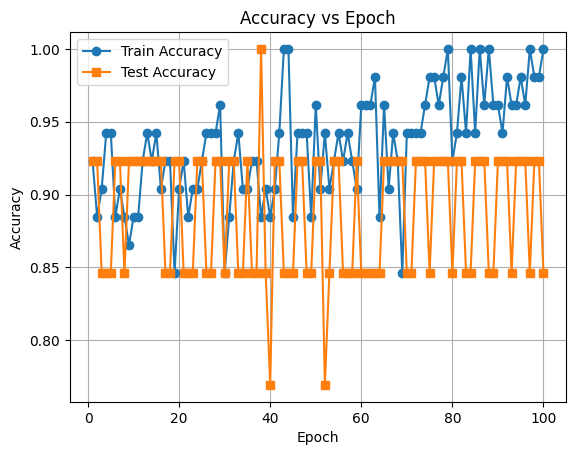

In [ ]:
def plot_accuracy_vs_epoch(train_acc_list, test_acc_list):
    epochs = np.arange(1, len(train_acc_list) + 1)
    plt.figure()
    plt.plot(epochs, train_acc_list, label='Train Accuracy', marker='o')
    plt.plot(epochs, test_acc_list, label='Test Accuracy', marker='s')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy vs Epoch')
    plt.grid(True)
    plt.legend()
    plt.show()
plot_accuracy_vs_epoch(train_acc_list, test_acc_list)